##### Setup

###### Imports

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor, Lambda

import numpy as np
import matplotlib.pyplot as plt

from svipy.vae import vaeEncoder, vaeDecoder, variationalAutoencoder
from svipy.model import reshape, earlyStopping

###### Load data

In [2]:
class imageOnlyDataset(torch.utils.data.Dataset):
    '''
    Class to extract only the images as labels not needed for VAEs.
    '''
    def __init__(self, original, index):
        self.__original = original
        self.__index = index

    @property
    def original(self):
        return self.__original

    @property
    def index(self):
        return self.__index

    def __len__(self):
        return len(self.original)

    def __getitem__(self, index):
        return self.original[index][self.index]

In [3]:
# ToTensor() scales eveything to [0, 1)
thresh = Lambda(lambda x: torch.where(ToTensor()(x) > 0.5, 1.0, 0.0))

# scatter_ to get a one-hot vector
onehot = Lambda(lambda y: torch.zeros(10, dtype=torch.float).scatter_(0, torch.tensor(y), value=1))

trainData = datasets.MNIST(root="../data", train=True, download=True, transform=thresh, target_transform=onehot)
testData = datasets.MNIST(root="../data", train=False, download=True, transform=thresh, target_transform=onehot)

trainImageData = imageOnlyDataset(trainData, 0)  # remove the labels as we dont need them
testImageData = imageOnlyDataset(testData, 0)
print(len(trainData), len(testData), len(trainImageData), len(testImageData))

60000 10000 60000 10000


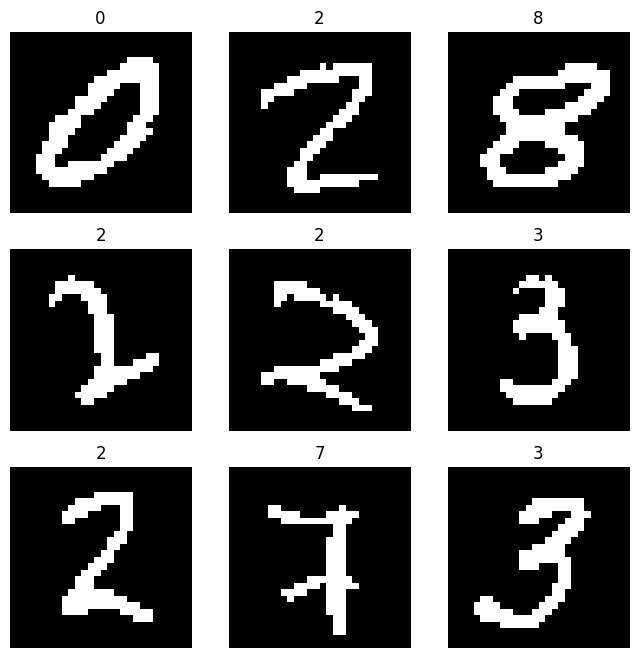

In [4]:
# show some randomly picked numbers
figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    sidx = torch.randint(len(trainData), size=(1,)).item()
    img, label = trainData[sidx]
    figure.add_subplot(rows, cols, i)
    plt.title(str(torch.argmax(label, dim=0).item()))
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap='gray')
plt.show()

###### Hardware Specs

In [5]:
cudaavailable = torch.cuda.is_available()
mpsavailable = torch.backends.mps.is_available()
curr_device = torch.cuda.current_device()

device = torch.device("cuda" if cudaavailable else "mps" if mpsavailable else "cpu")
device_count = torch.cuda.device_count() 
device_name =  torch.cuda.get_device_name(0)

print(f'Cuda available: {cudaavailable}')
print(f'Current device: {curr_device}')
print(f'Device: {device}')
print(f'Device count: {device_count}')
print(f'Device name: {device_name}')

Cuda available: True
Current device: 0
Device: cuda
Device count: 1
Device name: NVIDIA GeForce GTX 970


In [6]:
def latentSpaceRecons2D(model, n=30, figsize=15, scale=1.0):
    digit_size = 28
    figure = np.zeros((digit_size * n, digit_size * n))
    
    # linearly spaced coordinates corresponding in the 2D latent space
    grid_x = np.linspace(-scale, scale, n)
    grid_y = np.linspace(-scale, scale, n)[::-1]

    for i, yi in enumerate(grid_y):
        for j, xi in enumerate(grid_x):
            z_sample = torch.tensor([[xi, yi]], dtype=torch.float32).to(device)
            x_decoded = model.decoder(z_sample)[0].cpu().detach()
            digit = x_decoded[0].reshape(digit_size, digit_size)
            figure[i * digit_size : (i + 1) * digit_size,
                   j * digit_size : (j + 1) * digit_size] = digit

    plt.figure(figsize=(figsize, figsize))
    
    # set axis ticks corresponding to latent values
    start_range = digit_size // 2
    end_range = n * digit_size + start_range
    pixel_range = np.arange(start_range, end_range, digit_size)
    plt.xticks(pixel_range, np.round(grid_x, 1))
    plt.yticks(pixel_range, np.round(grid_y, 1))

    # axis labels
    plt.xlabel("z[0]")
    plt.ylabel("z[1]")
    
    plt.imshow(figure, cmap="Greys_r")
    plt.show()


def activeUnits(model, dataset, threshold=0.01, batchSize=256, device=device):
    """
    Burda et al.'s "active units" statistic: Var_x[mu(x)] per latent
    dimension, computed across the dataset. A dimension whose posterior
    mean barely moves across different inputs is \"dead\" -- carrying no
    information about x, regardless of what its logVar looks like.
    """
    
    model.eval()
    loader = DataLoader(dataset, batch_size=batchSize, shuffle=False)
    means = []
    with torch.no_grad():
        for data in loader:
            data = data.to(device)
            zMean, _ = model.encode(data)
            means.append(zMean.cpu())
    means = torch.cat(means, dim=0)
    
    variance = means.var(dim=0)
    nActive = 0
    for i, v in enumerate(variance):
        active = v.item() > threshold
        nActive += active
        print(f"dim {i}: Var_x[mu] = {v.item():.6f}  ({'active' if active else 'DEAD'})")
    
    print(f"{nActive}/{len(variance)} active units (threshold={threshold})")          
    return variance


##### MNIST

###### Variational Autoencoder

In [7]:
class sumBceDecoder(vaeDecoder):
    '''
    VAE decoder with cross entropy loss (canonical decoder uses MSE)
    '''
    @staticmethod
    def reconstructionLoss(x: torch.Tensor, recon: torch.Tensor) -> torch.Tensor:
        bce = torch.nn.functional.binary_cross_entropy(recon, x, reduction='none')
        return torch.mean(torch.sum(torch.flatten(bce, start_dim=1), dim=1))

In [8]:
# build the encoder and decoder networks
hid_dim = 2

encoder = nn.Sequential(nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, stride=2, padding=1),
                        nn.ReLU(),
                        nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=2, padding=1),
                        nn.ReLU(),
                        nn.Flatten(), # reshape([3136]), # 
                        nn.Linear(3136, hid_dim + hid_dim))
encoder = vaeEncoder(encoder)

decoder = nn.Sequential(nn.Linear(hid_dim, 32 * 7 * 7),
                        nn.ReLU(),
                        reshape([32, 7, 7]),
                        nn.ConvTranspose2d(in_channels=32, out_channels=64, kernel_size=3, stride=2, padding=1, output_padding=1),
                        nn.ReLU(),
                        nn.ConvTranspose2d(in_channels=64, out_channels=32, kernel_size=3, stride=2, padding=1, output_padding=1),
                        nn.ReLU(),
                        nn.ConvTranspose2d(in_channels=32, out_channels=1, kernel_size=3, stride=1, padding=1),
                        nn.Sigmoid())
decoder = sumBceDecoder(decoder)

model_vae_sum = variationalAutoencoder(encoder, decoder).to(device)

In [9]:
learning_rate = 0.001
batch_size = 128
epochs = 50

trainLoader = DataLoader(trainImageData, batch_size=batch_size, shuffle=True)
validLoader = DataLoader(testImageData, batch_size=batch_size, shuffle=True)
optimizer = torch.optim.Adam(model_vae_sum.parameters(), lr=learning_rate)
stopper = earlyStopping(patience=3, minDelta=0.1, mode='min', restoreBestWeights=True)

In [10]:
model_vae_sum.trainLoop(trainLoader, optimizer, epochs, 
                        reportIters=100, scheduler=None,
                        checkpointPath='../checkpoints/mnist_vae/',
                        checkPointName='vae_2',
                        validDataLoader=validLoader,
                        earlyStopper=stopper)

Epoch 1
-------------------------------
totalLoss: 202.593307 reconLoss: 199.041214 klLoss: 3.552090[12800/60000]
totalLoss: 184.462936 reconLoss: 180.730530 klLoss: 3.732406[25600/60000]
totalLoss: 170.430481 reconLoss: 166.901703 klLoss: 3.528780[38400/60000]
totalLoss: 170.788803 reconLoss: 167.365097 klLoss: 3.423713[51200/60000]
Validation Error: 169.368637
Epoch 2
-------------------------------
totalLoss: 166.380341 reconLoss: 163.232391 klLoss: 3.147954[12800/60000]
totalLoss: 154.591599 reconLoss: 151.208740 klLoss: 3.382855[25600/60000]
totalLoss: 159.603134 reconLoss: 156.172592 klLoss: 3.430541[38400/60000]
totalLoss: 156.183838 reconLoss: 152.903137 klLoss: 3.280702[51200/60000]
Validation Error: 159.092745
Epoch 3
-------------------------------
totalLoss: 154.076660 reconLoss: 150.672821 klLoss: 3.403831[12800/60000]
totalLoss: 154.204575 reconLoss: 150.816605 klLoss: 3.387963[25600/60000]
totalLoss: 163.625916 reconLoss: 160.285339 klLoss: 3.340581[38400/60000]
totalLos

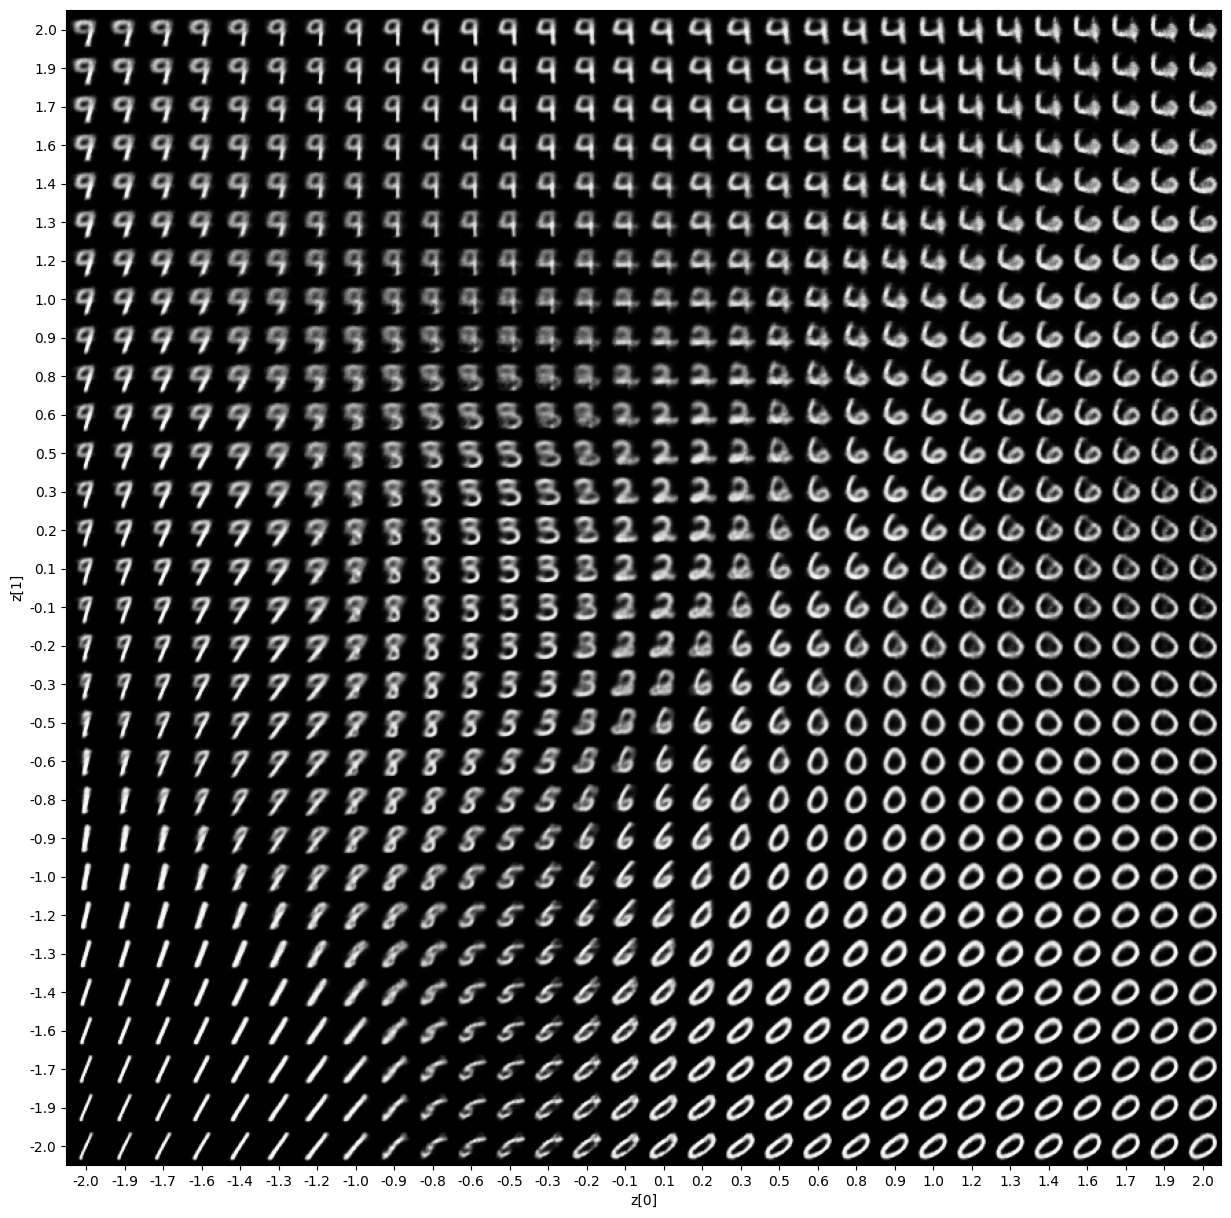

In [11]:
latentSpaceRecons2D(model_vae_sum, scale=2.0, n=30)

In [12]:
activeUnits(model_vae_sum, trainImageData)

dim 0: Var_x[mu] = 1.157946  (active)
dim 1: Var_x[mu] = 0.849967  (active)
2/2 active units (threshold=0.01)


tensor([1.1579, 0.8500])

###### Mode Collapse

In [13]:
class avgBceDecoder(vaeDecoder):
    """
    Replace sum of error with mean of error - helps to 
    make error independent of dimensionality
    """
    @staticmethod
    def reconstructionLoss(x: torch.Tensor, recon: torch.Tensor) -> torch.Tensor:
        bce = torch.nn.functional.binary_cross_entropy(recon, x, reduction='none')
        return torch.mean(torch.mean(torch.flatten(bce, start_dim=1), dim=1))

In [14]:
# build the encoder and decoder networks
hid_dim = 2

encoder = nn.Sequential(nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, stride=2, padding=1),
                        nn.ReLU(),
                        nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=2, padding=1),
                        nn.ReLU(),
                        nn.Flatten(), # reshape([3136]), # 
                        nn.Linear(3136, hid_dim + hid_dim))
encoder = vaeEncoder(encoder)

decoder = nn.Sequential(nn.Linear(hid_dim, 32 * 7 * 7),
                        nn.ReLU(),
                        reshape([32, 7, 7]),
                        nn.ConvTranspose2d(in_channels=32, out_channels=64, kernel_size=3, stride=2, padding=1, output_padding=1),
                        nn.ReLU(),
                        nn.ConvTranspose2d(in_channels=64, out_channels=32, kernel_size=3, stride=2, padding=1, output_padding=1),
                        nn.ReLU(),
                        nn.ConvTranspose2d(in_channels=32, out_channels=1, kernel_size=3, stride=1, padding=1),
                        nn.Sigmoid())
decoder = avgBceDecoder(decoder)

model_vae_avg = variationalAutoencoder(encoder, decoder).to(device)

In [15]:
learning_rate = 0.001
batch_size = 128
epochs = 50

trainLoader = DataLoader(trainImageData, batch_size=batch_size, shuffle=True)
validLoader = DataLoader(testImageData, batch_size=batch_size, shuffle=True)
optimizer = torch.optim.Adam(model_vae_avg.parameters(), lr=learning_rate)
stopper = earlyStopping(patience=3, minDelta=0.1, mode='min', restoreBestWeights=True)

In [16]:
model_vae_avg.trainLoop(trainLoader, optimizer, epochs, 
                        reportIters=100, scheduler=None,
                        checkpointPath='../checkpoints/mnist_vae/',
                        checkPointName='vae_2_avg',
                        validDataLoader=validLoader,
                        earlyStopper=stopper)

Epoch 1
-------------------------------
totalLoss: 0.273615 reconLoss: 0.273576 klLoss: 0.000039[12800/60000]
totalLoss: 0.263775 reconLoss: 0.263767 klLoss: 0.000007[25600/60000]
totalLoss: 0.262417 reconLoss: 0.262414 klLoss: 0.000003[38400/60000]
totalLoss: 0.260272 reconLoss: 0.260271 klLoss: 0.000001[51200/60000]
Validation Error: 0.264433
Epoch 2
-------------------------------
totalLoss: 0.265942 reconLoss: 0.265941 klLoss: 0.000001[12800/60000]
totalLoss: 0.261387 reconLoss: 0.261387 klLoss: 0.000001[25600/60000]
totalLoss: 0.266403 reconLoss: 0.266402 klLoss: 0.000001[38400/60000]
totalLoss: 0.263521 reconLoss: 0.263520 klLoss: 0.000001[51200/60000]
Validation Error: 0.263034
Epoch 3
-------------------------------
totalLoss: 0.276407 reconLoss: 0.276407 klLoss: 0.000000[12800/60000]
totalLoss: 0.267025 reconLoss: 0.267025 klLoss: 0.000000[25600/60000]
totalLoss: 0.264074 reconLoss: 0.264074 klLoss: 0.000000[38400/60000]
totalLoss: 0.255777 reconLoss: 0.255777 klLoss: 0.000000

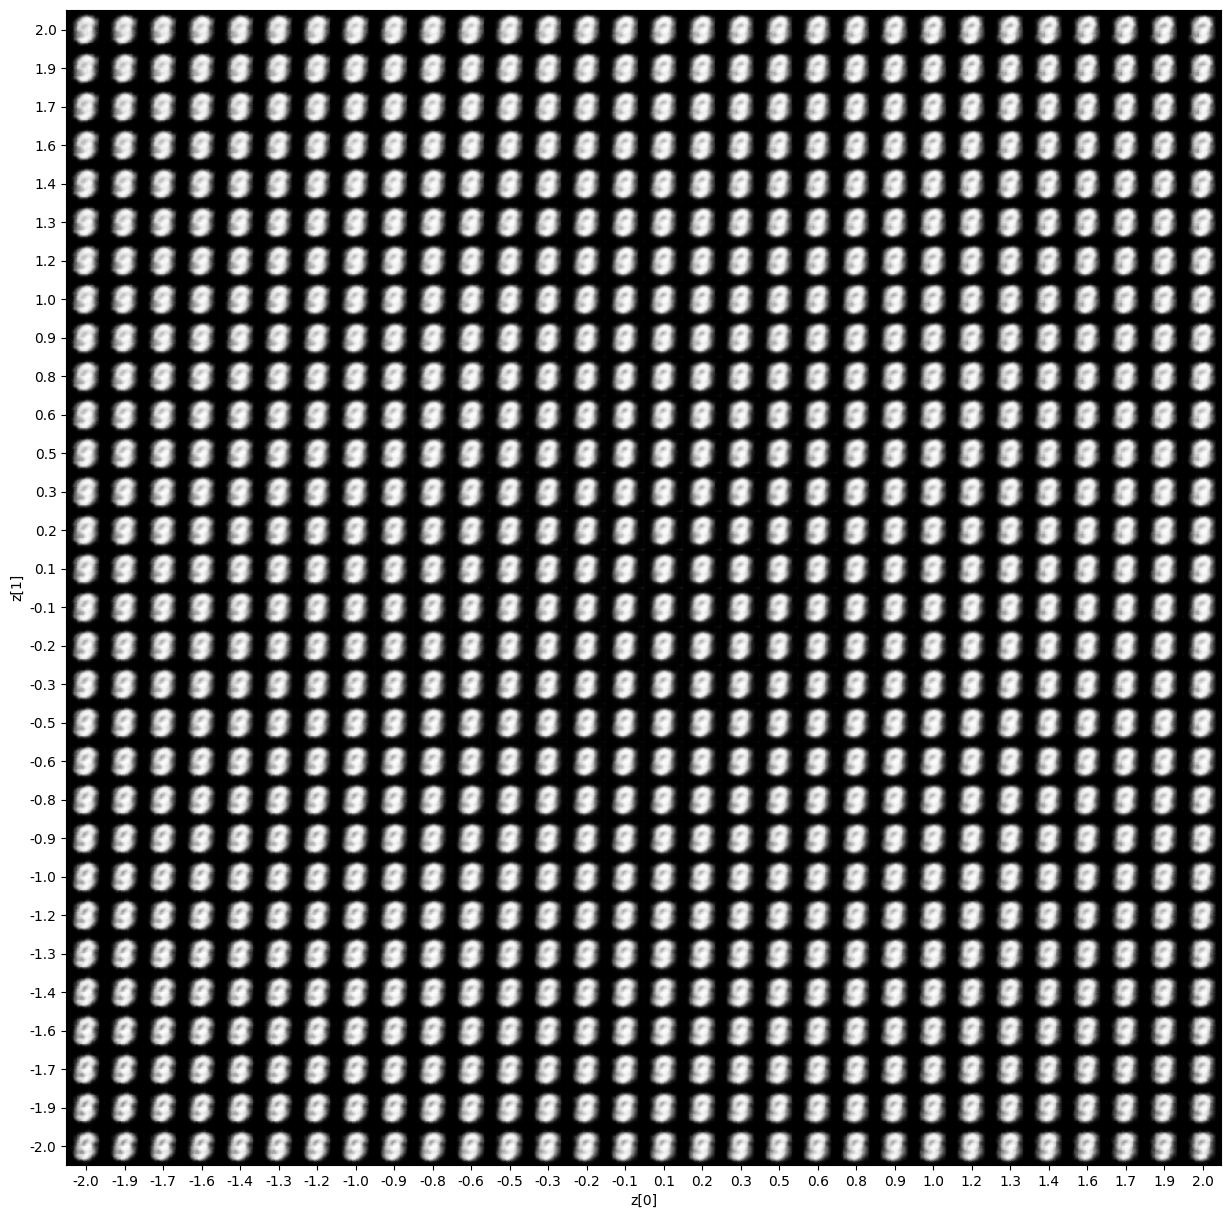

In [17]:
latentSpaceRecons2D(model_vae_avg, scale=2.0, n=30)

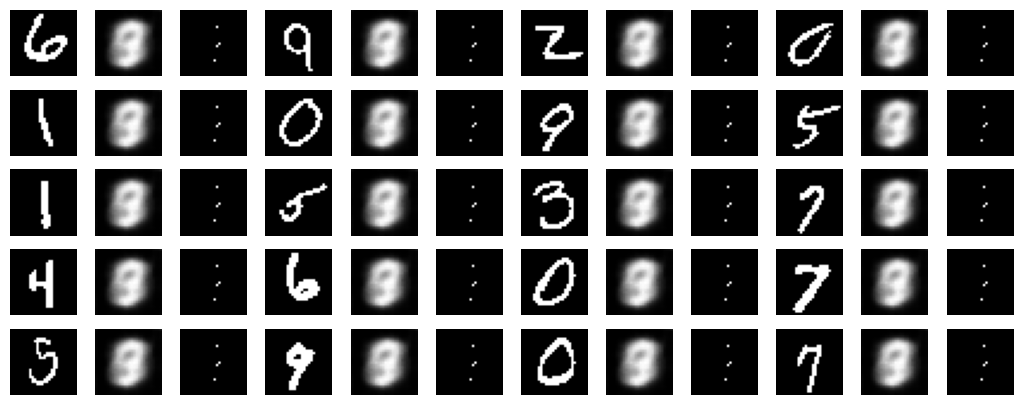

In [18]:
nCols = 12
nRows = 5

figure = plt.figure(figsize=(13, 5))
model_vae_avg.eval()

with torch.no_grad():
    for i in range(4 * nRows):
        sidx = torch.randint(len(trainData), size=(1,)).item()
        img, label = trainData[sidx]
        figure.add_subplot(nRows, nCols, 3 * i + 1)
        plt.axis("off")
        plt.imshow(img.squeeze(), cmap='gray')
        
        img = model_vae_avg.decode(model_vae_avg.encode(trainImageData[sidx].unsqueeze(0).to(device))[0])
        img = img.cpu().detach()
        figure.add_subplot(nRows, nCols, 3 * i + 2)
        plt.axis("off")
        plt.imshow(img.numpy().squeeze(), cmap='gray')

        figure.add_subplot(nRows, nCols, 3 * i + 3)
        plt.axis("off")
        plt.imshow(torch.where(img > 0.5, 1.0, 0.0).numpy().squeeze(), cmap='gray')

plt.show()

In [19]:
activeUnits(model_vae_avg, trainImageData)

dim 0: Var_x[mu] = 0.000001  (DEAD)
dim 1: Var_x[mu] = 0.000001  (DEAD)
0/2 active units (threshold=0.01)


tensor([6.2506e-07, 5.2922e-07])

###### β-VAE

In [20]:
# build the encoder and decoder networks
hid_dim = 2
beta = 0.01

encoder = nn.Sequential(nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, stride=2, padding=1),
                        nn.ReLU(),
                        nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=2, padding=1),
                        nn.ReLU(),
                        nn.Flatten(), # reshape([3136]), # 
                        nn.Linear(3136, hid_dim + hid_dim))
encoder = vaeEncoder(encoder)

decoder = nn.Sequential(nn.Linear(hid_dim, 32 * 7 * 7),
                        nn.ReLU(),
                        reshape([32, 7, 7]),
                        nn.ConvTranspose2d(in_channels=32, out_channels=64, kernel_size=3, stride=2, padding=1, output_padding=1),
                        nn.ReLU(),
                        nn.ConvTranspose2d(in_channels=64, out_channels=32, kernel_size=3, stride=2, padding=1, output_padding=1),
                        nn.ReLU(),
                        nn.ConvTranspose2d(in_channels=32, out_channels=1, kernel_size=3, stride=1, padding=1),
                        nn.Sigmoid())
decoder = avgBceDecoder(decoder)

model_bvae_avg = variationalAutoencoder(encoder, decoder, beta).to(device)

In [21]:
learning_rate = 1e-3
batch_size = 128
epochs = 50

trainLoader = DataLoader(trainImageData, batch_size=batch_size, shuffle=True)
validLoader = DataLoader(testImageData, batch_size=batch_size, shuffle=True)
optimizer = torch.optim.Adam(model_bvae_avg.parameters(), lr=learning_rate)
stopper = earlyStopping(patience=3, minDelta=0.001, mode='min', restoreBestWeights=True)

In [22]:
model_bvae_avg.trainLoop(trainLoader, optimizer, epochs, 
                         reportIters=100, scheduler=None,
                         checkpointPath='../checkpoints/mnist_bvae/',
                         checkPointName='bvae_2_2', 
                         validDataLoader=validLoader,
                         earlyStopper=stopper)

Epoch 1
-------------------------------
totalLoss: 0.287580 reconLoss: 0.280672 klLoss: 0.690792[12800/60000]
totalLoss: 0.247888 reconLoss: 0.235164 klLoss: 1.272366[25600/60000]
totalLoss: 0.242236 reconLoss: 0.227651 klLoss: 1.458499[38400/60000]
totalLoss: 0.228684 reconLoss: 0.214529 klLoss: 1.415467[51200/60000]
Validation Error: 0.227315
Epoch 2
-------------------------------
totalLoss: 0.223290 reconLoss: 0.208554 klLoss: 1.473592[12800/60000]
totalLoss: 0.219574 reconLoss: 0.203910 klLoss: 1.566421[25600/60000]
totalLoss: 0.223730 reconLoss: 0.207960 klLoss: 1.577011[38400/60000]
totalLoss: 0.221031 reconLoss: 0.205296 klLoss: 1.573588[51200/60000]
Validation Error: 0.220707
Epoch 3
-------------------------------
totalLoss: 0.213649 reconLoss: 0.196807 klLoss: 1.684198[12800/60000]
totalLoss: 0.229724 reconLoss: 0.212858 klLoss: 1.686610[25600/60000]
totalLoss: 0.217529 reconLoss: 0.199600 klLoss: 1.792878[38400/60000]
totalLoss: 0.224726 reconLoss: 0.207574 klLoss: 1.715199

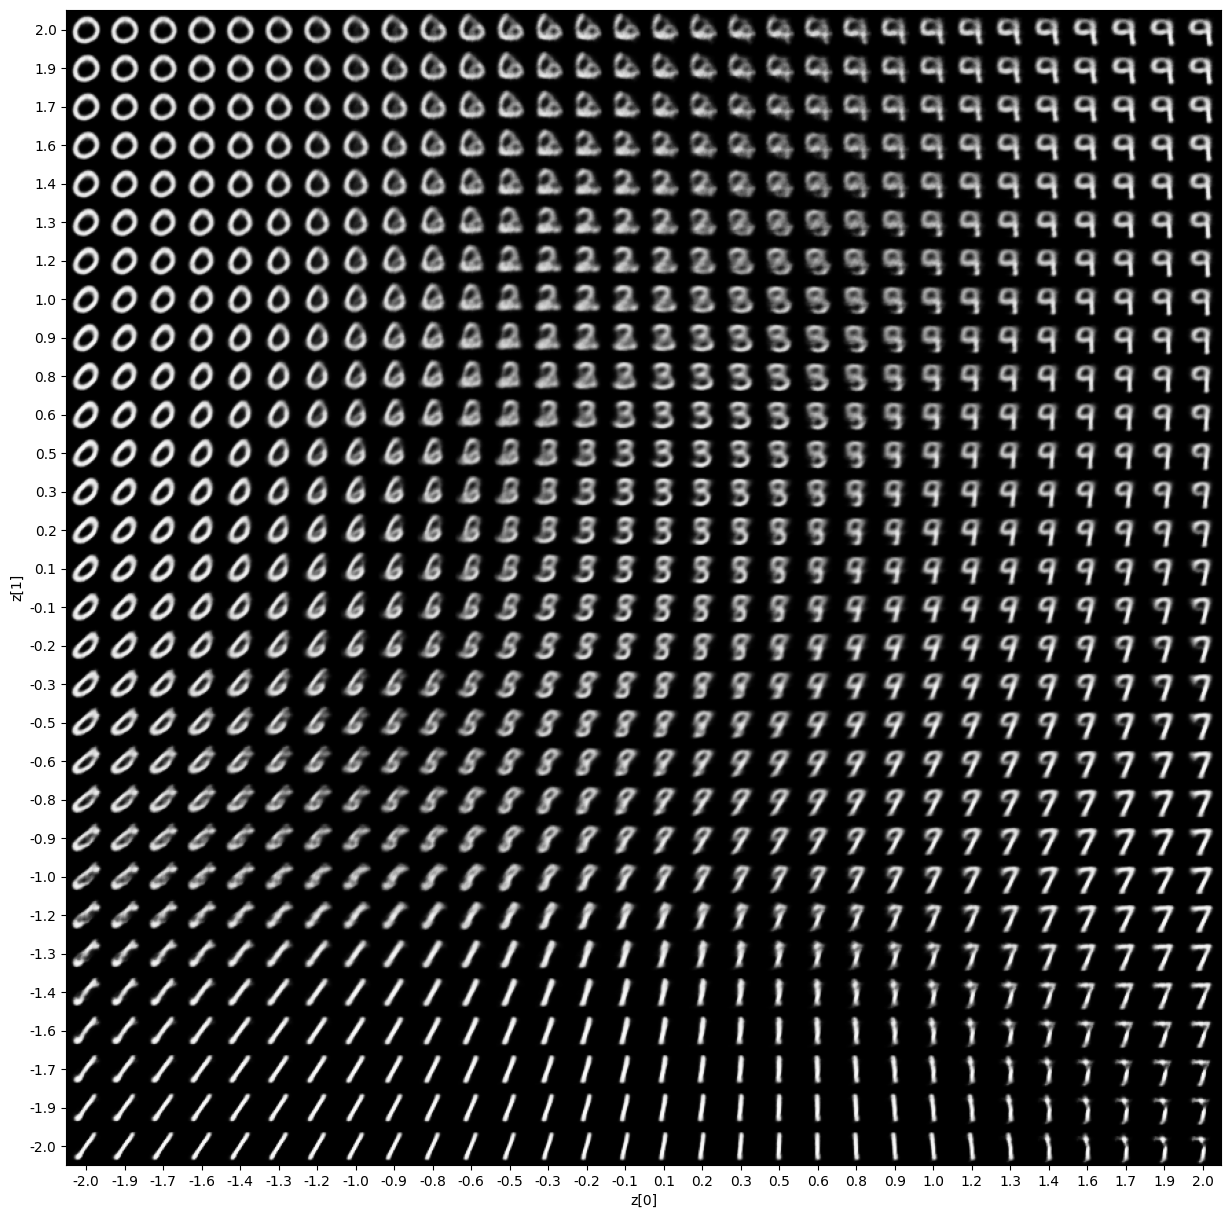

In [23]:
latentSpaceRecons2D(model_bvae_avg, scale=2.0, n=30)

In [24]:
activeUnits(model_bvae_avg, trainImageData)

dim 0: Var_x[mu] = 1.007574  (active)
dim 1: Var_x[mu] = 0.990191  (active)
2/2 active units (threshold=0.01)


tensor([1.0076, 0.9902])